# Assignment 22.00 - Part 01

## MountainCar testbed, analysis, and interpretability notebook

This notebook is the **standalone Part 01 deliverable** for the group assignment.
Running it from top to bottom will:

1. train or reload all Part 01 MountainCar experiments,
2. evaluate them under both **objective** and **engineered** rewards when relevant,
3. generate the figures and summary tables used for reporting,
4. analyse the learned policies numerically, visually, and with a simple explanation model.

The notebook is intentionally thin: the reusable logic lives in `src/part01/`,
while this document orchestrates and explains the full workflow.


## Assignment mapping

The implementation below addresses the main Part 01 requirements:

- **Design choices**: state discretisation, action representations, reward variants, hyperparameters, and RL algorithm selection.
- **Custom environment adaptations**: reward wrappers for discrete action-cost scenarios.
- **Framework / modularisation**: the notebook imports a reusable package instead of duplicating logic.
- **Evaluation**: mean reward, variability, success rate, step count, control effort, and physical reach.
- **Policy analysis**: heatmaps, policy disagreement maps, phase trajectories, and feature-importance explanations.
- **Comparative policy analysis**: baseline discrete, on-policy discrete, two adapted discrete environments, and continuous control.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import os

from part01.analysis import (
    build_summary_frame,
    explain_policy_with_random_forest,
    generate_all_figures,
    plot_continuous_policy_heatmap,
    plot_discrete_policy_heatmaps,
    plot_objective_vs_engineered_reward,
    plot_phase_trajectories,
    plot_policy_disagreement,
    plot_training_dashboard,
    save_summary_tables,
    plot_sb3_phase_trajectories,
    plot_ppo_policy_heatmap,
    plot_dqn_policy_heatmap,
    plot_algorithm_comparison
)
from part01.config import PART01_EXPERIMENTS, PLOTS_DIR, TABLES_DIR
from part01.pipeline import evaluate_all_experiments, run_all_experiments, save_evaluation_rows

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)


## Experiment catalogue

These are the scenarios included in the Part 01 framework:

- **Discrete baseline (Q-learning)**: minimum-step objective on `MountainCar-v0`
- **Discrete baseline (SARSA)**: on-policy comparison on `MountainCar-v0`
- **Discrete directional-cost adaptation**: different costs for left vs right thrust
- **Discrete non-null-action adaptation**: linear penalty for every non-idle action
- **Continuous MountainCar**: discretised thrust controller on `MountainCarContinuous-v0`


In [2]:
experiment_frame = pd.DataFrame([config.to_dict() for config in PART01_EXPERIMENTS])
experiment_frame[[
    "slug",
    "title",
    "env_id",
    "algorithm",
    "state_bins",
    "episodes",
    "training_wrapper",
    "description",
]]


,slug,title,env_id,algorithm,state_bins,episodes,training_wrapper,description
0,discrete_q_learning,Discrete MountainCar - Q-learning baseline,MountainCar-v0,q_learning,"(40, 40)",3500,none,Baseline discrete-control solution. Objective:...
1,discrete_sarsa,Discrete MountainCar - SARSA baseline,MountainCar-v0,sarsa,"(40, 40)",3500,none,On-policy baseline used to compare how a more ...
2,discrete_directional_cost,Discrete MountainCar - directional action cost,MountainCar-v0,q_learning,"(40, 40)",4000,directional_cost,Adapted discrete environment where left and ri...
3,discrete_non_null_cost,Discrete MountainCar - non-null action cost,MountainCar-v0,q_learning,"(40, 40)",4000,uniform_cost,Adapted discrete environment with a linear pen...
4,continuous_q_learning,Continuous MountainCar - discretised-action Q-...,MountainCarContinuous-v0,q_learning,"(36, 28)",5000,continuous_energy,Continuous-action variant solved with a tabula...
5,discrete_dqn,Discrete MountainCar - DQN,MountainCar-v0,dqn,None,300000,none,Deep Q-Network on the native discrete action s...
6,continuous_ppo,Continuous MountainCar - PPO,MountainCarContinuous-v0,ppo,None,500000,continuous_energy,Proximal Policy Optimisation on the continuous...


## Reproducibility controls

- `OVERWRITE_MODELS = False` means cached artifacts are reused if they already exist.
- `USE_TENSORBOARD = False` keeps the notebook lightweight by default.
- Set `OVERWRITE_MODELS = True` if you want to retrain everything from scratch.


In [20]:
OVERWRITE_MODELS = False
USE_TENSORBOARD = False

artifacts = run_all_experiments(
    experiments=PART01_EXPERIMENTS,
    overwrite=True,
    tensorboard=USE_TENSORBOARD,
)


[discrete_q_learning] episode  250 | avg shaped reward  -200.00 | epsilon 0.4718
[discrete_q_learning] episode  500 | avg shaped reward  -200.00 | epsilon 0.2226
[discrete_q_learning] episode  750 | avg shaped reward  -200.00 | epsilon 0.1050
[discrete_q_learning] episode 1000 | avg shaped reward  -200.00 | epsilon 0.0500
[discrete_q_learning] episode 1250 | avg shaped reward  -200.00 | epsilon 0.0500
[discrete_q_learning] episode 1500 | avg shaped reward  -200.00 | epsilon 0.0500
[discrete_q_learning] episode 1750 | avg shaped reward  -200.00 | epsilon 0.0500
[discrete_q_learning] episode 2000 | avg shaped reward  -199.88 | epsilon 0.0500
[discrete_q_learning] episode 2250 | avg shaped reward  -199.64 | epsilon 0.0500
[discrete_q_learning] episode 2500 | avg shaped reward  -199.51 | epsilon 0.0500
[discrete_q_learning] episode 2750 | avg shaped reward  -199.42 | epsilon 0.0500
[discrete_q_learning] episode 3000 | avg shaped reward  -197.22 | epsilon 0.0500
[discrete_q_learning] episod

/Users/kareemhawwash/Desktop/study/Renforcement Learning/Project/RLgroupproject/venv/lib/python3.13/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


[continuous_ppo] steps   10,000 | avg reward (last 50 eps)    76.27
[continuous_ppo] steps   20,000 | avg reward (last 50 eps)   101.31
[continuous_ppo] steps   30,000 | avg reward (last 50 eps)    87.42
[continuous_ppo] steps   40,000 | avg reward (last 50 eps)    86.07
[continuous_ppo] steps   50,000 | avg reward (last 50 eps)   114.31
[continuous_ppo] steps   60,000 | avg reward (last 50 eps)   115.52
[continuous_ppo] steps   70,000 | avg reward (last 50 eps)   135.40
[continuous_ppo] steps   80,000 | avg reward (last 50 eps)   139.00
[continuous_ppo] steps   90,000 | avg reward (last 50 eps)   139.92
[continuous_ppo] steps  100,000 | avg reward (last 50 eps)   140.06
[continuous_ppo] steps  110,000 | avg reward (last 50 eps)   140.26
[continuous_ppo] steps  120,000 | avg reward (last 50 eps)   140.11
[continuous_ppo] steps  130,000 | avg reward (last 50 eps)   140.49
[continuous_ppo] steps  140,000 | avg reward (last 50 eps)   140.51
[continuous_ppo] steps  150,000 | avg reward (la

## Evaluation tables

The next cells evaluate each learned policy on:

- its **objective/native reward** environment, and
- when the training reward was shaped, also on the **engineered reward** environment.

This is important because Part 01 asks us to compare actual performance against
the reward signal used during optimisation.


In [22]:
evaluation_rows = evaluate_all_experiments(artifacts, experiments=PART01_EXPERIMENTS)
save_evaluation_rows(evaluation_rows)

summary_frame = build_summary_frame(evaluation_rows)
save_summary_tables(summary_frame)

summary_frame


,slug,title,env_id,algorithm,reward_mode,episodes,mean_reward,std_reward,mean_raw_reward,mean_penalty,mean_steps,success_rate,mean_non_null_actions,mean_left_actions,mean_right_actions,mean_squared_action_sum,mean_max_position,mean_final_position,success_rate_pct
0,discrete_directional_cost,Discrete MountainCar - directional action cost,MountainCar-v0,q_learning,objective,150,-186.966660,13.705190,-186.966660,0.000000,186.966667,0.493333,135.813333,60.053333,75.760000,135.813339,0.245998,0.214095,49.333333
1,discrete_dqn,Discrete MountainCar - DQN,MountainCar-v0,sb3,objective,150,-162.686667,14.399137,NaN,NaN,162.686667,0.980000,NaN,NaN,NaN,NaN,0.532322,0.527099,98.000000
2,discrete_non_null_cost,Discrete MountainCar - non-null action cost,MountainCar-v0,q_learning,objective,150,-194.286667,7.106182,-194.286667,0.000000,194.286667,0.586667,139.166667,65.466667,73.700000,139.166672,0.336306,0.036830,58.666667
3,discrete_q_learning,Discrete MountainCar - Q-learning baseline,MountainCar-v0,q_learning,objective,150,-190.086670,9.358730,-190.086670,0.000000,190.086667,0.786667,153.040000,73.213333,79.826667,153.039993,0.481396,0.438322,78.666667
4,discrete_sarsa,Discrete MountainCar - SARSA baseline,MountainCar-v0,sarsa,objective,150,-198.586670,5.142226,-198.586670,0.000000,198.586667,0.073333,147.640000,71.086667,76.553333,147.639999,0.299284,0.034863,7.333333
5,continuous_ppo,Continuous MountainCar - PPO,MountainCarContinuous-v0,sb3,objective,150,93.662170,0.033350,NaN,NaN,66.193333,1.000000,NaN,NaN,NaN,NaN,0.467134,0.467134,100.000000
6,continuous_q_learning,Continuous MountainCar - discretised-action Q-...,MountainCarContinuous-v0,q_learning,objective,150,91.475830,1.315979,91.475830,0.000000,129.980000,1.000000,120.366667,46.520000,73.846667,85.241669,0.455924,0.455924,100.000000
7,discrete_directional_cost,Discrete MountainCar - directional action cost,MountainCar-v0,q_learning,training,150,-205.498001,15.241706,-187.139999,18.358000,187.140000,0.486667,134.513333,61.333333,73.180000,134.513336,0.231256,0.202892,48.666667
8,discrete_non_null_cost,Discrete MountainCar - non-null action cost,MountainCar-v0,q_learning,training,150,-212.631989,5.804331,-196.199997,16.432001,196.200000,0.426667,136.933333,67.006667,69.926667,136.933334,0.276231,-0.182066,42.666667
9,continuous_q_learning,Continuous MountainCar - discretised-action Q-...,MountainCarContinuous-v0,q_learning,training,150,263.585846,2.524488,91.202919,-172.382919,133.173333,1.000000,122.833333,45.933333,76.900000,87.970833,0.456404,0.456404,100.000000


In [23]:
objective_summary = summary_frame[summary_frame["reward_mode"] == "objective"].copy()
objective_summary = objective_summary.sort_values(
    ["success_rate", "mean_reward", "mean_steps"],
    ascending=[False, False, True],
)
objective_summary


,slug,title,env_id,algorithm,reward_mode,episodes,mean_reward,std_reward,mean_raw_reward,mean_penalty,mean_steps,success_rate,mean_non_null_actions,mean_left_actions,mean_right_actions,mean_squared_action_sum,mean_max_position,mean_final_position,success_rate_pct
5,continuous_ppo,Continuous MountainCar - PPO,MountainCarContinuous-v0,sb3,objective,150,93.662170,0.033350,NaN,NaN,66.193333,1.000000,NaN,NaN,NaN,NaN,0.467134,0.467134,100.000000
6,continuous_q_learning,Continuous MountainCar - discretised-action Q-...,MountainCarContinuous-v0,q_learning,objective,150,91.475830,1.315979,91.475830,0.0,129.980000,1.000000,120.366667,46.520000,73.846667,85.241669,0.455924,0.455924,100.000000
1,discrete_dqn,Discrete MountainCar - DQN,MountainCar-v0,sb3,objective,150,-162.686667,14.399137,NaN,NaN,162.686667,0.980000,NaN,NaN,NaN,NaN,0.532322,0.527099,98.000000
3,discrete_q_learning,Discrete MountainCar - Q-learning baseline,MountainCar-v0,q_learning,objective,150,-190.086670,9.358730,-190.086670,0.0,190.086667,0.786667,153.040000,73.213333,79.826667,153.039993,0.481396,0.438322,78.666667
2,discrete_non_null_cost,Discrete MountainCar - non-null action cost,MountainCar-v0,q_learning,objective,150,-194.286667,7.106182,-194.286667,0.0,194.286667,0.586667,139.166667,65.466667,73.700000,139.166672,0.336306,0.036830,58.666667
0,discrete_directional_cost,Discrete MountainCar - directional action cost,MountainCar-v0,q_learning,objective,150,-186.966660,13.705190,-186.966660,0.0,186.966667,0.493333,135.813333,60.053333,75.760000,135.813339,0.245998,0.214095,49.333333
4,discrete_sarsa,Discrete MountainCar - SARSA baseline,MountainCar-v0,sarsa,objective,150,-198.586670,5.142226,-198.586670,0.0,198.586667,0.073333,147.640000,71.086667,76.553333,147.639999,0.299284,0.034863,7.333333


## Training behaviour and convergence

The dashboard below compares:

- shaped reward,
- native/objective reward,
- rolling success rate,
- maximum position reached during training.


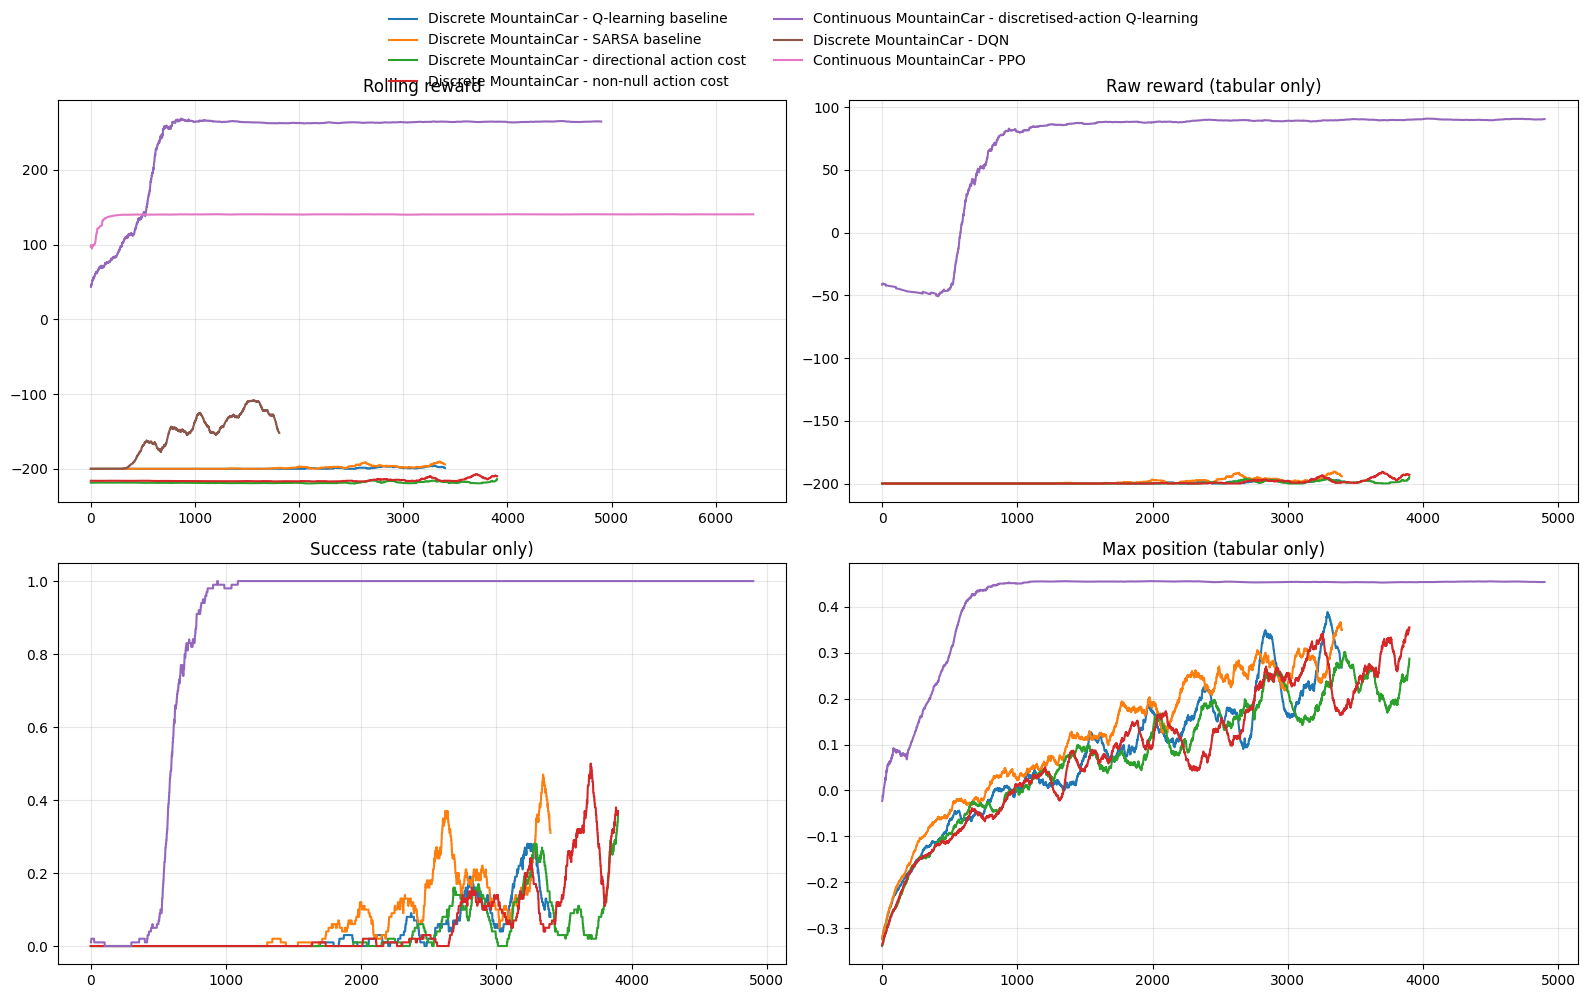

In [24]:
fig, training_dashboard_path = plot_training_dashboard(artifacts)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/dashboard.png", bbox_inches="tight")
Image("results/part01/plots/dashboard.png")

## Policy structure

Discrete experiments use the same 3-action interface, so their greedy policies can
be compared directly. The continuous controller is shown separately as a thrust map.


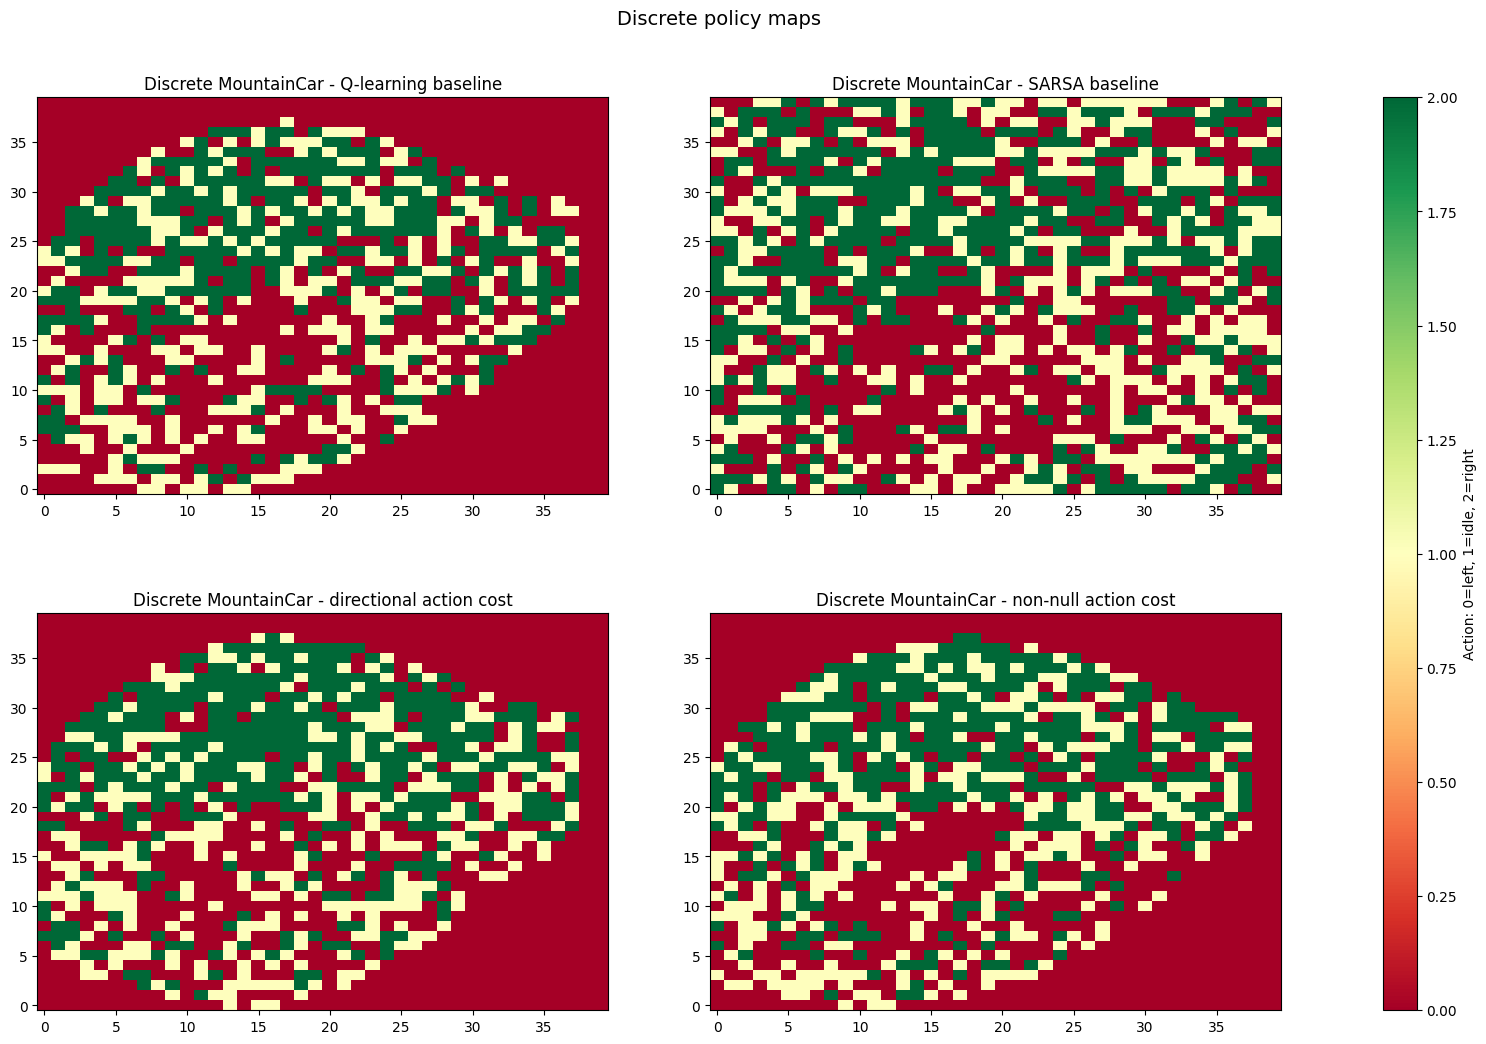

In [25]:
fig, _ = plot_discrete_policy_heatmaps(artifacts)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/discrete_policy_heatmaps.png", bbox_inches="tight")
Image("results/part01/plots/discrete_policy_heatmaps.png")


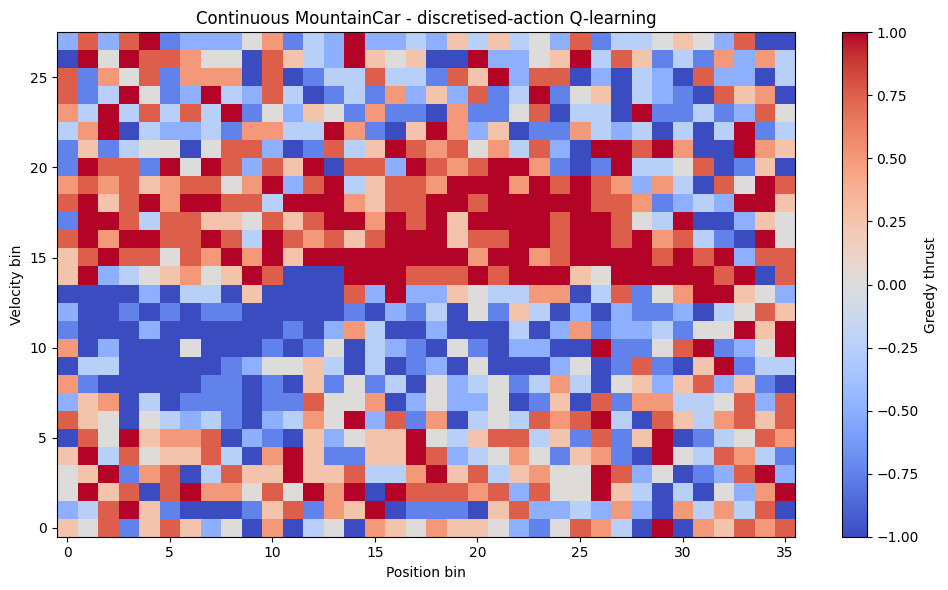

In [26]:
fig, continuous_policy_path = plot_continuous_policy_heatmap(artifacts["continuous_q_learning"])
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/continuous_policy.png", bbox_inches="tight")
Image("results/part01/plots/continuous_policy.png")


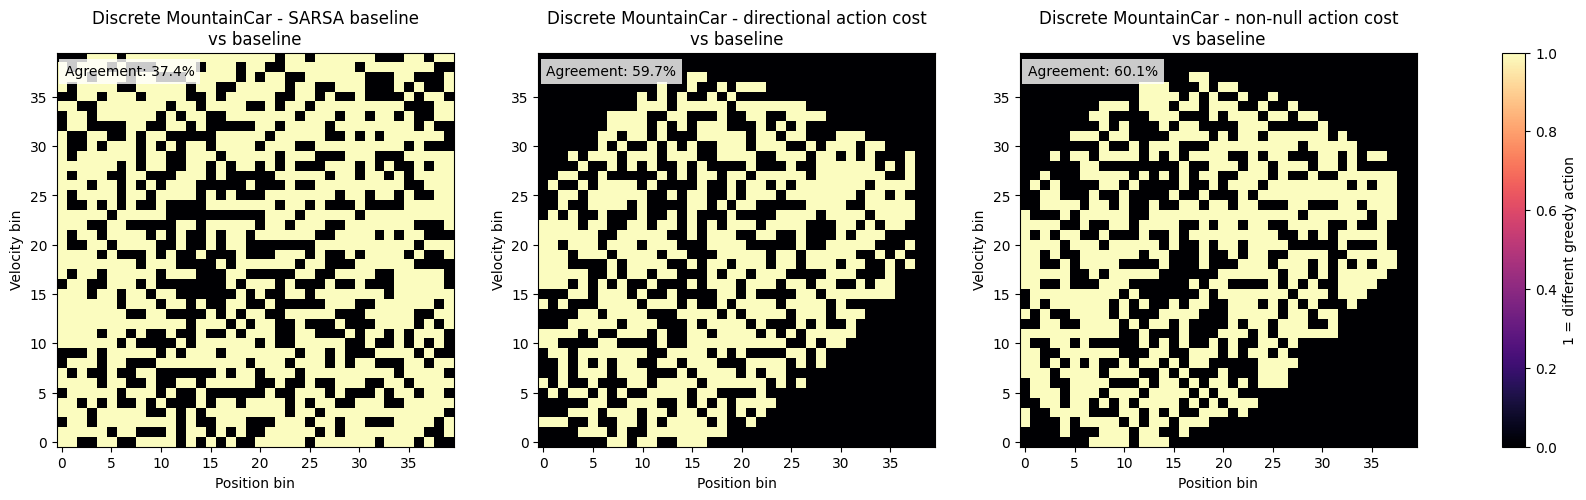

In [27]:
fig, disagreement_path = plot_policy_disagreement(artifacts)
os.makedirs("results/part01/plots", exist_ok=True)  
fig.savefig("results/part01/plots/disagreement.png", bbox_inches="tight")
Image("results/part01/plots/disagreement.png")


## Objective reward vs engineered reward

For the adapted discrete environments, we explicitly compare the reward used during
training with the original environment reward. This reveals whether a shaped reward
helps the agent optimise the true task or simply a proxy objective.


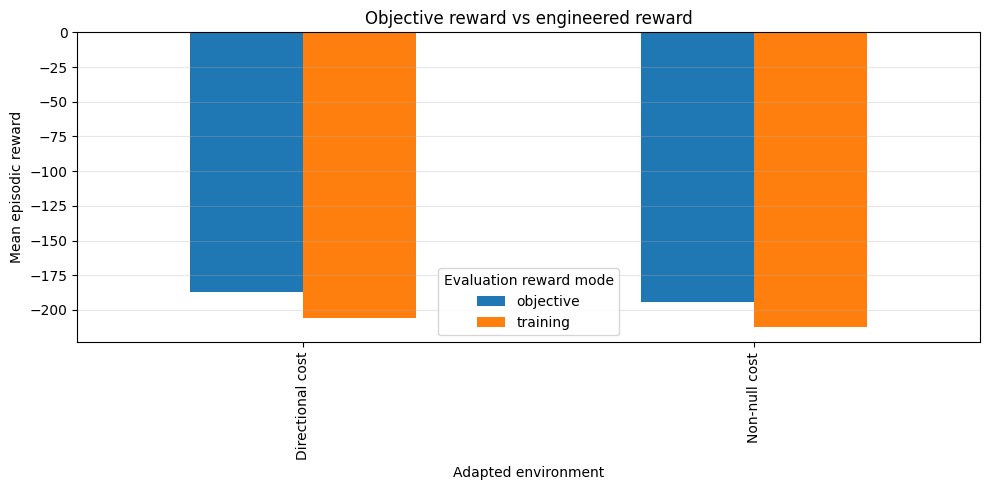

In [28]:
fig, reward_tradeoff_path = plot_objective_vs_engineered_reward(summary_frame)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/reward_tradeoff.png", bbox_inches="tight")
Image("results/part01/plots/reward_tradeoff.png")


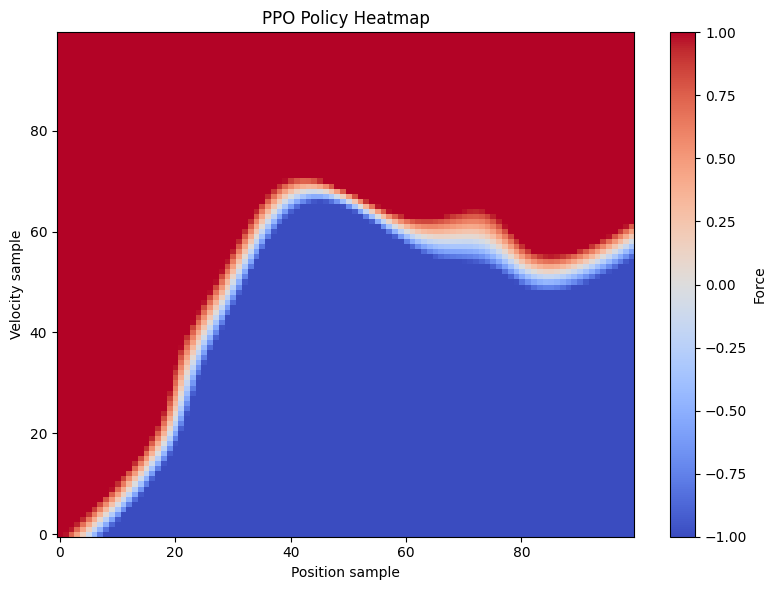

In [29]:
ppo_artifact = artifacts["continuous_ppo"]
fig, _ = plot_ppo_policy_heatmap(ppo_artifact["model"], None)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/ppo_policy_heatmap.png", bbox_inches="tight")
Image("results/part01/plots/ppo_policy_heatmap.png")

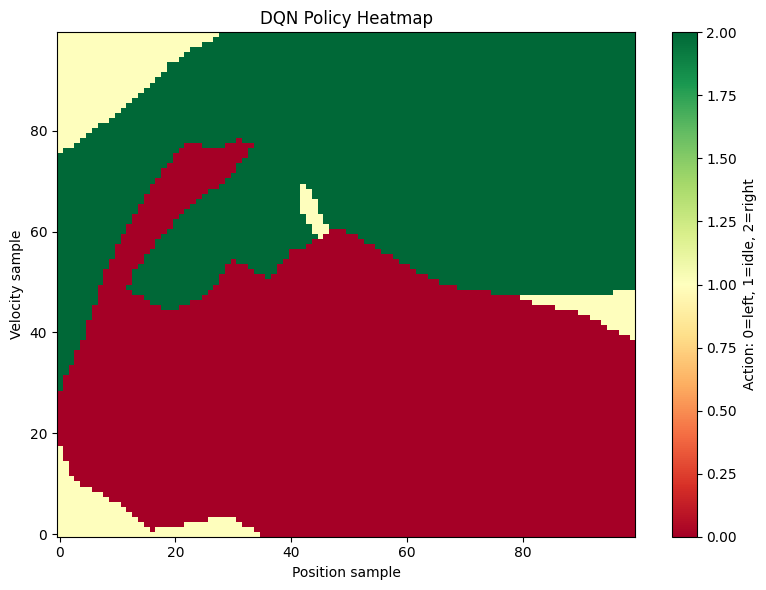

In [30]:
dqn_artifact = artifacts["discrete_dqn"]
fig, _ = plot_dqn_policy_heatmap(dqn_artifact["model"], None)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/dqn_policy_heatmap.png", bbox_inches="tight")
Image("results/part01/plots/dqn_policy_heatmap.png")

In [32]:
summary_rows = evaluate_all_experiments(artifacts)
summary_df = build_summary_frame(summary_rows)

/Users/kareemhawwash/Desktop/study/Renforcement Learning/Project/RLgroupproject/src/part01/analysis.py:571: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 5))


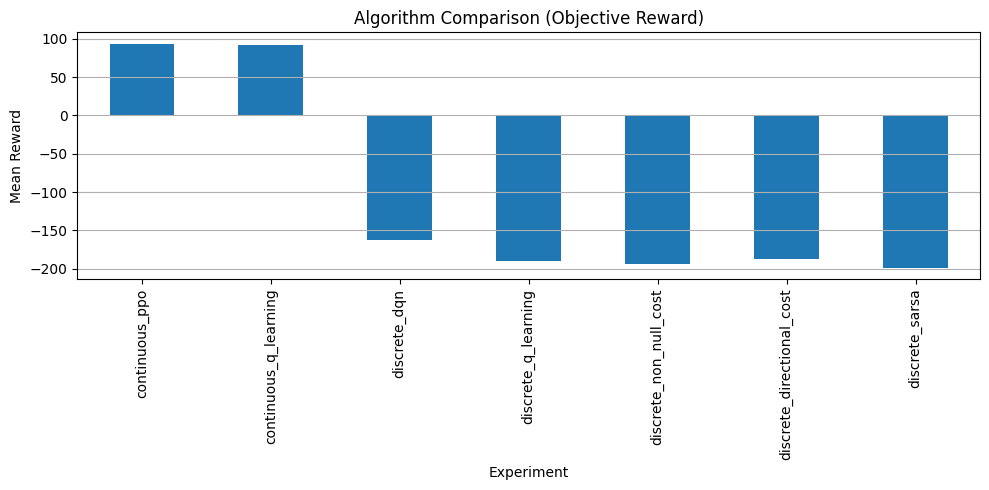

In [33]:
fig, _ = plot_algorithm_comparison(summary_df)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/algorithm_comparison.png", bbox_inches="tight")
Image("results/part01/plots/algorithm_comparison.png")

## Physical interpretation through trajectories

Phase-space trajectories show whether the learned control law follows the expected
MountainCar strategy: first build momentum by moving away from the goal, then
convert that momentum into enough energy to climb the right hill.


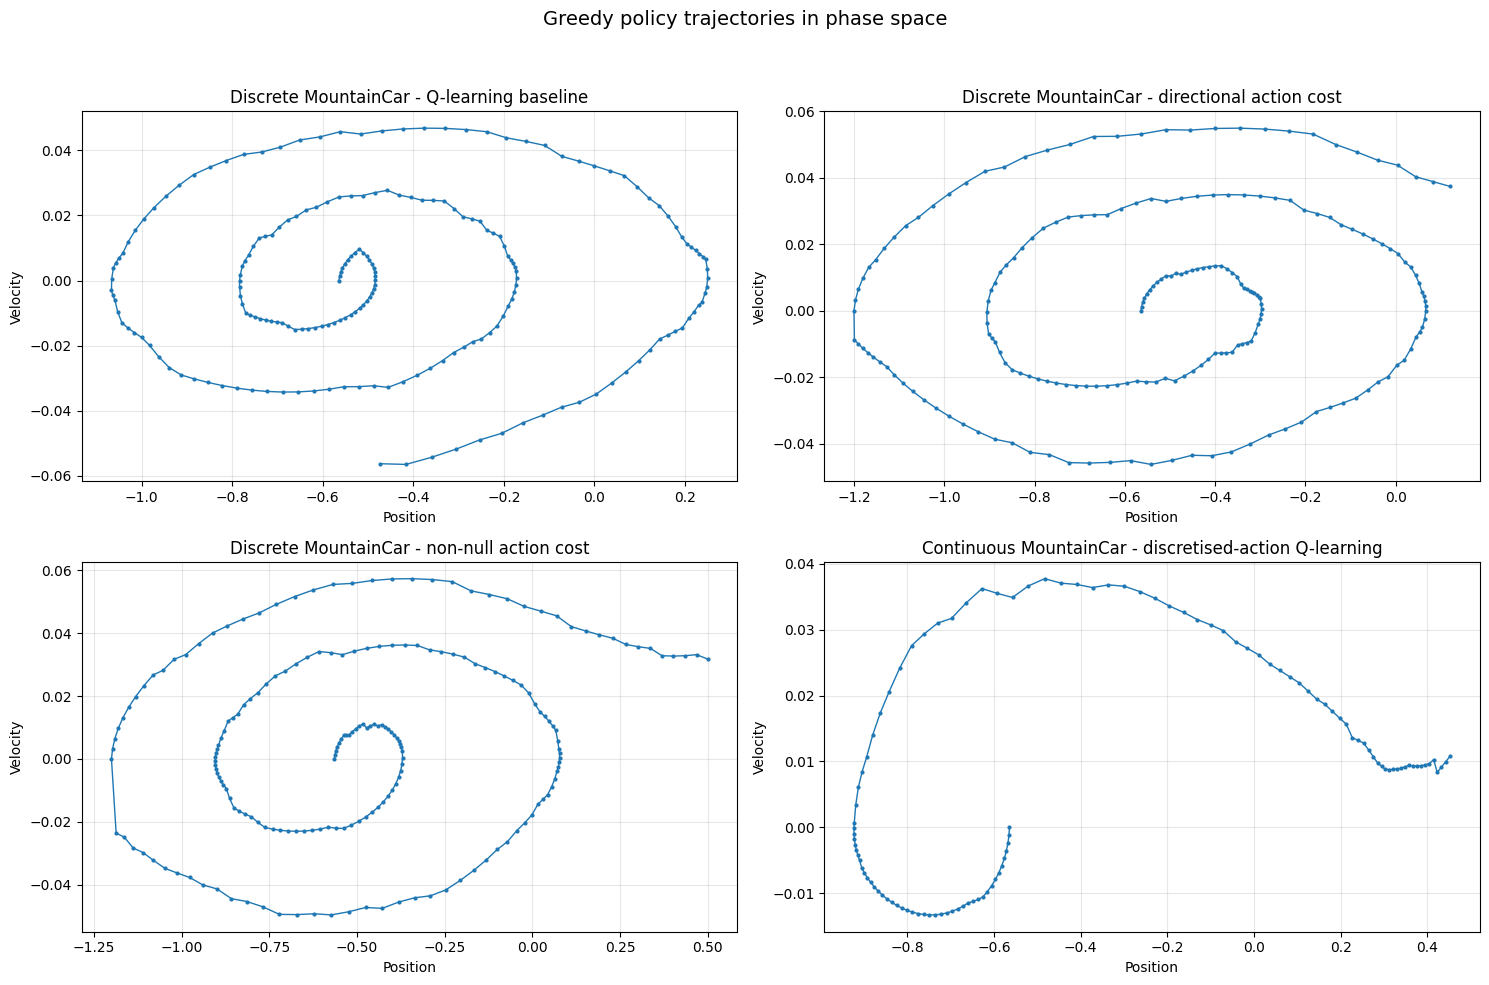

In [34]:
fig, trajectory_path = plot_phase_trajectories(artifacts)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/trajectories.png", bbox_inches="tight")
Image("results/part01/plots/trajectories.png")


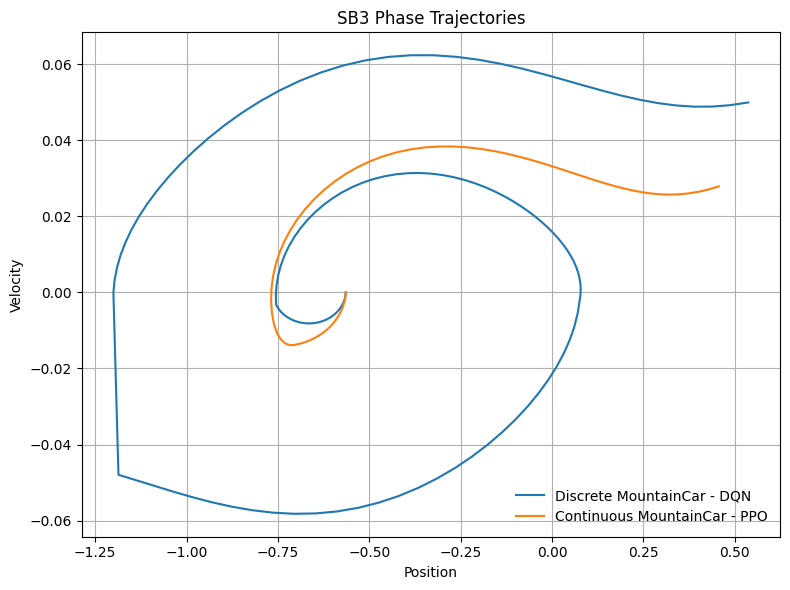

In [35]:
fig, plot_sb__trajectories = plot_sb3_phase_trajectories(artifacts)
os.makedirs("results/part01/plots", exist_ok=True)
fig.savefig("results/part01/plots/sb3_trajectories.png", bbox_inches="tight")
Image("results/part01/plots/sb3_trajectories.png")

## Explanation model

To make the baseline policy more interpretable, we train a **random-forest surrogate**
that predicts the greedy action from engineered physical descriptors:

- position,
- velocity,
- absolute velocity,
- momentum proxy,
- kinetic energy,
- height proxy.

High surrogate accuracy means the learned tabular policy can be approximated by a
simple explanatory model, while the feature importances reveal which state concepts
drive the action choice most strongly.


In [36]:
explanation = explain_policy_with_random_forest(
    artifacts["discrete_q_learning"]["config"],
    artifacts["discrete_q_learning"]["q_table"],
)
explanation["importance"]


momentum_proxy    0.230613
velocity          0.196058
height_proxy      0.159859
position          0.146450
kinetic_energy    0.136430
abs_velocity      0.130590
dtype: float64

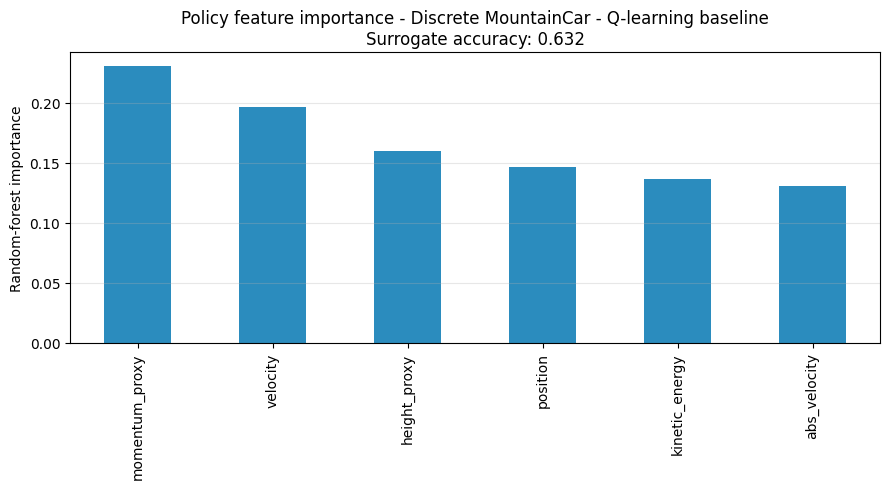

In [37]:
fig = explanation["figure"]
fig.savefig("results/part01/plots/importance.png", bbox_inches="tight")
Image("results/part01/plots/importance.png")


## Deliverable outputs

The generated artifacts are saved under `results/part01/`:

- `models/` - learned Q-tables
- `logs/` - training histories and metadata
- `plots/` - figures for the report/presentation
- `tables/` - evaluation summaries in JSON, CSV, and Markdown


In [38]:
sorted(path.name for path in PLOTS_DIR.glob("*.png"))


['algorithm_comparison.png',
 'continuous_policy.png',
 'continuous_policy_heatmap.png',
 'discrete_policy.png',
 'discrete_policy_heatmaps.png',
 'discrete_q_learning_feature_importance.png',
 'dqn_policy_heatmap.png',
 'importance.png',
 'objective_vs_engineered_reward.png',
 'phase_trajectories.png',
 'policy_disagreement.png',
 'ppo_policy_heatmap.png',
 'reward_tradeoff.png',
 'sb3_phase_trajectories.png',
 'training_dashboard.png']

## Final interpretation prompts

Use the tables and figures above to support the written discussion:

- Which controller gives the best **objective** performance?
- Which reward shaping strategy best balances **goal-reaching** and **control effort**?
- How does the continuous controller differ structurally from the discrete ones?
- Which state variables dominate the learned policy according to the surrogate model?

These questions align with the Part 01 requirement to justify the solution both
numerically and from the physical perspective of the MountainCar dynamics.
